In [750]:
import pandas as pd
import sqlite3
import tabulate
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

<font size = 7> Phase 1 : "Import and CLean Data"


### Import Cleaned dataset


In [751]:
pd.set_option('display.max_columns', None)

#Read Car List dataframe and show maximum columns
 
df_CarList = pd.read_csv("full_vehicles_dataset.csv")
df_CarList_Cleaned = df_CarList.info(max_cols=20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 906 entries, 0 to 905
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            906 non-null    object 
 1   description     854 non-null    object 
 2   make            906 non-null    object 
 3   model           906 non-null    object 
 4   type            906 non-null    object 
 5   year            906 non-null    int64  
 6   price           906 non-null    float64
 7   engine          905 non-null    object 
 8   cylinders       906 non-null    object 
 9   fuel            899 non-null    object 
 10  mileage         874 non-null    float64
 11  transmission    906 non-null    object 
 12  trim            906 non-null    object 
 13  body            906 non-null    object 
 14  doors           902 non-null    float64
 15  exterior_color  902 non-null    object 
 16  interior_color  869 non-null    object 
 17  drivetrain      906 non-null    obj

In [752]:
#Making sure it grabs data for 2024 vehicles only
df_CarList_Cleaned = df_CarList[df_CarList['year'] == 2024]
df_CarList_Cleaned.reset_index(drop=True, inplace=True)

Find missing values


In [753]:
df_CarList_Cleaned[df_CarList_Cleaned.isnull().any(axis=1)]

,name,description,make,model,type,year,price,engine,cylinders,fuel,mileage,transmission,trim,body,doors,exterior_color,interior_color,drivetrain
2,2024 GMC Yukon XL Denali,NaN,GMC,Yukon XL,New,2024,96410.0,"6.2L V-8 gasoline direct injection, variable v...",8.0,Gasoline,0.0,Automatic,Denali,SUV,4.0,Summit White,Teak/Light Shale,Four-wheel Drive
7,2024 Hyundai Tucson Hybrid Limited,NaN,Hyundai,Tucson Hybrid,New,2024,42230.0,16V GDI DOHC Turbo Hybrid,4.0,Hybrid,5.0,6-Speed Automatic,Limited,SUV,4.0,White Pearl,Black,All-wheel Drive
22,2024 GMC Terrain Denali,NaN,GMC,Terrain,New,2024,44120.0,"4 gasoline direct injection, DOHC, variable va...",4.0,Gasoline,0.0,Automatic,Denali,SUV,4.0,Ebony,Jet Blk,All-wheel Drive
26,2024 Chrysler Pacifica Touring-L,\n \n $750 off MSRP! 2024 Chrysler...,Chrysler,Pacifica,New,2024,48705.0,24V MPFI DOHC,6.0,Gasoline,NaN,9-Speed Automatic,Touring-L,Passenger Van,4.0,Diamond Black,Black,All-wheel Drive
37,2024 GMC Terrain SLE,NaN,GMC,Terrain,New,2024,35870.0,"4 gasoline direct injection, DOHC, variable va...",4.0,Gasoline,0.0,Automatic,SLE,SUV,4.0,Summit White,Jet Blk Premium Clth,All-wheel Drive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
879,2024 Ford Escape Active,NaN,Ford,Escape,New,2024,29305.0,12V PDI DOHC Turbo,3.0,Gasoline,10.0,8-Speed Automatic,Active,SUV,4.0,Carbonized Gray Metallic,Ebony,Front-wheel Drive
881,2024 Kia Sportage SX-Prestige,NaN,Kia,Sportage,New,2024,35195.0,16V PDI DOHC,4.0,Gasoline,10.0,8-Speed Automatic,SX-Prestige,SUV,4.0,Ebony Black,Black,Front-wheel Drive
884,2024 Kia Forte LXS,\n \n 2024 Kia Forte Steel Gray LX...,Kia,Forte,New,2024,21070.0,16V MPFI DOHC,4.0,Gasoline,NaN,Automatic CVT,LXS,Sedan,4.0,Steel Gray,Black,Front-wheel Drive
889,2024 Hyundai Tucson Hybrid SEL Convenience,NaN,Hyundai,Tucson Hybrid,New,2024,37220.0,16V GDI DOHC Turbo Hybrid,4.0,Hybrid,5.0,6-Speed Automatic,SEL Convenience,SUV,4.0,Deep Sea,Gray,All-wheel Drive


<font size="4">We have 252 rows of missing values. Lets clean this up by removing uneccessary columns and remove rows with NaN values


In [754]:
#Saves cleaned data to a new file
df_CarList_Cleaned.drop(columns=["description","fuel","type","engine","interior_color","exterior_color","mileage","doors"], inplace=True)

df_CarList_Cleaned.drop_duplicates()

,name,make,model,year,price,cylinders,transmission,trim,body,drivetrain
0,2024 Jeep Wagoneer Series II,Jeep,Wagoneer,2024,74600.0,6.0,8-Speed Automatic,Series II,SUV,Four-wheel Drive
1,2024 Jeep Grand Cherokee Laredo,Jeep,Grand Cherokee,2024,50170.0,6.0,8-Speed Automatic,Laredo,SUV,Four-wheel Drive
2,2024 GMC Yukon XL Denali,GMC,Yukon XL,2024,96410.0,8.0,Automatic,Denali,SUV,Four-wheel Drive
3,2024 RAM 3500 Laramie,RAM,3500,2024,81663.0,6.0,6-Speed Automatic,Laramie,Pickup Truck,Four-wheel Drive
4,2024 Nissan Murano Platinum,Nissan,Murano,2024,46000.0,6.0,Automatic CVT,Platinum,SUV,All-wheel Drive
...,...,...,...,...,...,...,...,...,...,...
900,2024 RAM 2500 Tradesman,RAM,2500,2024,69315.0,6.0,Automatic,Tradesman,Pickup Truck,Four-wheel Drive
901,2024 Mercedes-Benz Sprinter 2500 Standard Roof,Mercedes-Benz,Sprinter 2500,2024,59037.0,4.0,9-Speed Automatic,Standard Roof,Cargo Van,Rear-wheel Drive
903,2024 Jeep Wagoneer Base,Jeep,Wagoneer,2024,69085.0,6.0,8-Speed Automatic,Base,SUV,Four-wheel Drive
904,2024 Nissan Murano SV Intelligent AWD,Nissan,Murano,2024,43495.0,6.0,Automatic,SV Intelligent AWD,SUV,All-wheel Drive


In [755]:
# CHecking for any missing values
df_CarList_Cleaned.isnull().sum()

name            0
make            0
model           0
year            0
price           0
cylinders       0
transmission    0
trim            0
body            0
drivetrain      0
dtype: int64

In [756]:
#Replacing NaN vaules in cyclinder with 'Eletric' for the Electric Vehicles
df_CarList_Cleaned['cylinders']= df_CarList_Cleaned['cylinders'].fillna("Electric")

#Filling missing values in transmiddion column
df_CarList_Cleaned['transmission']=df_CarList_Cleaned['transmission'].fillna("Automatic")

#Adding SUV to NaNs in the column 'body'
df_CarList_Cleaned['body']=df_CarList_Cleaned['body'].fillna("SUV")

#Finding avg for missing prices and filling the missing price value
df_CarList_Cleaned['price'] = df_CarList_Cleaned['price'].fillna(df_CarList_Cleaned.groupby('model')['price'].transform('mean'))
df_CarList_Cleaned[df_CarList_Cleaned.isnull().any(axis=1)]

#Recheck missing values
df_CarList_Cleaned[df_CarList_Cleaned.isnull().any(axis=1)]

,name,make,model,year,price,cylinders,transmission,trim,body,drivetrain


In [757]:
# Filling any missing values in price column with a average
df_CarList_Cleaned['price'] = df_CarList_Cleaned['price'].fillna(df_CarList_Cleaned.groupby('make')['price'].transform('mean'))
df_CarList_Cleaned[df_CarList_Cleaned.isnull().any(axis=1)]

# Create lower casing values for 'Make' and 'Model' before joining other dataset
df_CarList_Cleaned["make"] = df_CarList_Cleaned["make"].str.lower().str.strip()
df_CarList_Cleaned["model"] = df_CarList_Cleaned["model"].str.lower().str.strip()
print(df_CarList_Cleaned.info)
df_CarList_Cleaned.head(15)

<bound method DataFrame.info of                                                name           make  \
0                      2024 Jeep Wagoneer Series II           jeep   
1                   2024 Jeep Grand Cherokee Laredo           jeep   
2                          2024 GMC Yukon XL Denali            gmc   
3                             2024 RAM 3500 Laramie            ram   
4                       2024 Nissan Murano Platinum         nissan   
..                                              ...            ...   
901  2024 Mercedes-Benz Sprinter 2500 Standard Roof  mercedes-benz   
902          2024 Dodge Hornet Hornet R/T Plus Eawd          dodge   
903                         2024 Jeep Wagoneer Base           jeep   
904           2024 Nissan Murano SV Intelligent AWD         nissan   
905                2024 Chevrolet Silverado 2500 WT      chevrolet   

              model  year    price cylinders  \
0          wagoneer  2024  74600.0       6.0   
1    grand cherokee  2024  5017

,name,make,model,year,price,cylinders,transmission,trim,body,drivetrain
0,2024 Jeep Wagoneer Series II,jeep,wagoneer,2024,74600.0,6.0,8-Speed Automatic,Series II,SUV,Four-wheel Drive
1,2024 Jeep Grand Cherokee Laredo,jeep,grand cherokee,2024,50170.0,6.0,8-Speed Automatic,Laredo,SUV,Four-wheel Drive
2,2024 GMC Yukon XL Denali,gmc,yukon xl,2024,96410.0,8.0,Automatic,Denali,SUV,Four-wheel Drive
3,2024 RAM 3500 Laramie,ram,3500,2024,81663.0,6.0,6-Speed Automatic,Laramie,Pickup Truck,Four-wheel Drive
4,2024 Nissan Murano Platinum,nissan,murano,2024,46000.0,6.0,Automatic CVT,Platinum,SUV,All-wheel Drive
5,2024 Jeep Wagoneer Base,jeep,wagoneer,2024,63862.0,6.0,8-Speed Automatic,Base,SUV,Rear-wheel Drive
6,2024 Ford F-350 Lariat Super Duty,ford,f-350,2024,89978.0,8.0,10-Speed Automatic,Lariat Super Duty,Pickup Truck,Four-wheel Drive
7,2024 Hyundai Tucson Hybrid Limited,hyundai,tucson hybrid,2024,42230.0,4.0,6-Speed Automatic,Limited,SUV,All-wheel Drive
8,2024 Jeep Grand Cherokee Altitude,jeep,grand cherokee,2024,42773.0,6.0,Automatic,Altitude,SUV,Four-wheel Drive
9,2024 Jeep Compass Latitude,jeep,compass,2024,37743.0,4.0,8-Speed Automatic,Latitude,SUV,Four-wheel Drive


In [758]:
print(df_CarList_Cleaned['make'].unique())

['jeep' 'gmc' 'ram' 'nissan' 'ford' 'hyundai' 'chevrolet' 'volkswagen'
 'dodge' 'chrysler' 'kia' 'mazda' 'acura' 'subaru' 'audi' 'bmw' 'toyota'
 'buick' 'mercedes-benz' 'honda' 'lincoln' 'cadillac' 'infiniti' 'lexus'
 'land rover' 'volvo' 'jaguar' 'genesis']


<font size="5">Dataset #1 Cleaned!


### Begin cleaning second dataset


In [759]:
df_rcl = pd.read_csv("RCL_FROM_2020_2024.csv")

pd.set_option('display.max_columns', None)

#Read Car List dataframe and show maximum columns
df_rcl_cleaned = df_rcl.info(max_cols=20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215506 entries, 0 to 215505
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   NHTSA ID       215506 non-null  object
 1   DOCUMENT NAME  215506 non-null  object
 2   MAKE           215506 non-null  object
 3   MODEL          215506 non-null  object
 4   MODEL YEAR     215506 non-null  int64 
 5   SUMMARY        215505 non-null  object
dtypes: int64(1), object(5)
memory usage: 9.9+ MB


<font size = 4> Renaming columns to match casing and likeness of other dataset before join


In [760]:
df_rcl.rename(columns={'MODEL YEAR': 'year'}, inplace=True)
df_rcl.rename(columns={'MAKE': 'make'}, inplace=True)
df_rcl.rename(columns={'MODEL': 'model'}, inplace=True)
df_rcl.rename(columns={'SUMMARY': 'summary'}, inplace=True)
df_rcl.rename(columns={'DOCUMENT NAME': 'file'}, inplace=True)
print(df_rcl.info)
df_rcl.head(20)

<bound method DataFrame.info of        NHTSA ID                   file      make          model  year  \
0        20E003  RCRIT-20E003-7585.pdf   CUMMINS  POWERDRIVE EV  9999   
1        20E003   RCMN-20E003-7457.pdf   CUMMINS  POWERDRIVE EV  9999   
2        20E004  RMISC-20E004-5516.pdf  FREEDMAN     BENCH SEAT  9999   
3        20E004  RMISC-20E004-6489.pdf  FREEDMAN     BENCH SEAT  9999   
4        20E004  RMISC-20E004-6489.pdf  FREEDMAN  FOLDAWAY SEAT  9999   
...         ...                    ...       ...            ...   ...   
215501   24V970  RCRIT-24V970-4111.pdf    INDIAN    SCOUT SIXTY  2025   
215502   24V970  RMISC-24V970-1551.pdf    INDIAN    SCOUT SIXTY  2025   
215503   24V970   RCMN-24V970-7276.pdf    INDIAN    SCOUT SIXTY  2025   
215504   24V970   RCMN-24V970-1200.pdf    INDIAN    SCOUT SIXTY  2025   
215505   24V970   RCMN-24V970-8406.pdf    INDIAN    SCOUT SIXTY  2025   

                                                  summary  
0       This document contains 

,NHTSA ID,file,make,model,year,summary
0,20E003,RCRIT-20E003-7585.pdf,CUMMINS,POWERDRIVE EV,9999,This document contains the field action campai...
1,20E003,RCMN-20E003-7457.pdf,CUMMINS,POWERDRIVE EV,9999,This document is an OEM notice to inform the a...
2,20E004,RMISC-20E004-5516.pdf,FREEDMAN,BENCH SEAT,9999,product recall notification letter
3,20E004,RMISC-20E004-6489.pdf,FREEDMAN,BENCH SEAT,9999,Final copy - customer notification letter
4,20E004,RMISC-20E004-6489.pdf,FREEDMAN,FOLDAWAY SEAT,9999,Final copy - customer notification letter
5,20E004,RMISC-20E004-5516.pdf,FREEDMAN,FOLDAWAY SEAT,9999,product recall notification letter
6,20E009,RCMN-20E009-4111.pdf,TOW KING,12K TOP WIND JACK,9999,"NOTICE TO DEALERS OF DEFECT, REMEDY INSTRUCTIO..."
7,20E013,RCMN-20E013-2751.pdf,BMW,BRAKE FLUID RES. COVER,9999,Manufacturer Notice to Dealers
8,20E013,RIONL-20E013-7354.pdf,BMW,BRAKE FLUID RES. COVER,9999,Interim Owner Notification Letter
9,20E013,RCMN-20E013-6045.pdf,BMW,BRAKE FLUID RES. COVER,9999,Manufacturer Notices to Dealers


<font size="4">Grabbing data for only 2024 vehicles, and checking for missing values.


In [761]:
df_rcl_cleaned = df_rcl[df_rcl["year"] == 2024]
df_rcl_cleaned.reset_index(drop=True, inplace=True)
df_rcl_cleaned.isnull().sum()
df_rcl_cleaned.head()

,NHTSA ID,file,make,model,year,summary
0,22V909,RCONL-22V909-2556.pdf,IC BUS,CESB,2024,22527; 02/06/2023; IC Bus; CE - 2022 & 2023; R...
1,22V909,RCRIT-22V909-1126.pdf,IC BUS,CESB,2024,22527; 02/01/2023; IC bus; CE - 2022 & 2023; R...
2,23V065,RCONL-23V065-7947.pdf,IC BUS,CESB,2024,"23501; 04/03/2023; IC Bus; 2022 thru 2024 CE, ..."
3,23V065,RCRIT-23V065-4342.pdf,IC BUS,CESB,2024,"23501; 04/03/2023; IC Bus; 2022 thru 2024 CE, ..."
4,23V087,RCONL-23V087-5040.pdf,KENWORTH,T280,2024,Attached letter is the FINAL customer notifica...


<font size="4">Check and remove duplicate lines.


In [762]:
df_rcl_cleaned.drop_duplicates()
df_rcl_cleaned[df_rcl_cleaned.isnull().any(axis=1)]
print(df_rcl_cleaned .info)

<bound method DataFrame.info of      NHTSA ID                   file                  make     model  year  \
0      22V909  RCONL-22V909-2556.pdf                IC BUS      CESB  2024   
1      22V909  RCRIT-22V909-1126.pdf                IC BUS      CESB  2024   
2      23V065  RCONL-23V065-7947.pdf                IC BUS      CESB  2024   
3      23V065  RCRIT-23V065-4342.pdf                IC BUS      CESB  2024   
4      23V087  RCONL-23V087-5040.pdf              KENWORTH      T280  2024   
...       ...                    ...                   ...       ...   ...   
9458   24V966  RCONL-24V966-6482.pdf  STORYTELLER OVERLAND    MYSTIC  2024   
9459   24V966   RCMN-24V966-1472.pdf  STORYTELLER OVERLAND   STEALTH  2024   
9460   24V966  RCONL-24V966-6482.pdf  STORYTELLER OVERLAND   STEALTH  2024   
9461   24V968  RCONL-24V968-6389.pdf  STORYTELLER OVERLAND  GXV HILT  2024   
9462   24V968   RCMN-24V968-0243.pdf  STORYTELLER OVERLAND  GXV HILT  2024   

                               

<font size="4">Remove Semi Trucks, Trailer, Three-wheelers etc. and all other vechicles not intended for daily drivers. This data is for the purpose of regular non commercial drivers.


In [763]:
non_vehicles = ("MACK", "KENWORTH", "TOW KING", "MCI", "CUMMINS", "LIGHTING EMOTORS", "SPARTAN FIRE", "AGILITY FUEL SYSTEMS", "MOPAR", "RUGGED LINERS", "ALTEC", "KEYSTONE", "THOMAS BUILT BUSES",
                "CARRIER TRANSICOLD", "PITTSBURGH AUTOMOTIVE", "FREEDMAN", "KZRN", "PJ TRAILERS", "LODE KING", "NEXUS", "TIFFIN", "WINNEBAGO", "NIKOLA", "VINFAST", "HOLIDAY RAMBLER",
                "JAYCO", "HEARTLAND", "PRATT INTERNATIONAL", "CFMOTO", "XOS", "AIRSTREAM", "INDIAN", "WESTERN STAR", "CAN-AM", "MAINTAINER", "NOVA BUS", "THOR MOTOR COACH", "FREIGHTLINER",
                "PETERBILT", "UTILITY TRAILER", "ARCIMOTO", "NEW FLYER", "KIDRON", "LION", "TICO", "SUPER PRODUCTS", "HINO", "AUTOCAR", "TRIPPLE E", "TRIPLE R", "KAWASAKI", "SCHWARZE", 
                "KZRZ", "TRAIL KING", "CRUISER RV", "TEREX", "TEREX ADVANCED", "INTERNATIONAL", "IC BUS", "FCCC", "VERMEER", "FOREST RIVER BUS", "HUSQVARNA", "KTM", "ZERO", "VAN HOOL",
                "FLEETWOOD", "BRUAN AMBULANCE", "FEILD VAN", "STORYTELLER OVERLAND", "KME", "SAFARI CONDO", "CUMMINS POWER GENERATION", "MITSUBISHI FUSO", "POLESTAR",
                "AKRON BRASS COMPANY", "TEKONSHA", "DANA", "DOMETIC", "DANA", "LIPPERT", "CODE 3", "AC DELCO", "NAPA", "SAAB", "DRAW-TITE", "TIMPTE", "STARCRAFT BUS", "ENDERA", "MICRO BIRD",
                "BRINKLEY RV", "COACHMEN", "FOREST RIVER", "DELCO TRAILERS", "DOOSAN PORTABLE POWER", "MOTIV", "TAXA", "DOOSAN", "LIVEWIRE", "ROSENBAUER", "CRUISER", "MORBARK", 
                "KENTUCY TRAILER KY", "kentucky trailer", "HARLEY-DAVIDSON", "ROYAL ENFIELD", "CATALINA", "DYNAMAX", "EAST TO WEST", "ATC", "NEWMAR", "AURORA", "VANCRAFT", 
                "OLIVER TRAVEL TRAILERS", "triumph", "PIERCE", "VIKING TRAVEL TRAILERS", "triple e", "triple e rv", "foretravel", "highland ridge", "chinook", "wilson", "brightdrop",
                "reading truck equipment", "clipper towable", "rich speciality trailers", "viking towable", "glaval bus", "crossroads", "dutchmen", "cushman", "great dane", "elkhart",
                "entegra", "big tex", "champion", "eldorado", "mobility trans", "braunability")

# Clearing off all unwanted vechicles
df_rcl_cleaned = df_rcl_cleaned[~df_rcl_cleaned['make'].isin(non_vehicles)]
df_rcl_cleaned.reset_index(drop=True, inplace=True)

# Check for missing values
df_rcl_cleaned[df_rcl_cleaned.isnull().any(axis=1)]

,NHTSA ID,file,make,model,year,summary


In [764]:
# View data
print(df_rcl_cleaned.info)
df_rcl_cleaned.head(20)


<bound method DataFrame.info of      NHTSA ID                   file   make model  year  \
0      23V173  RCRIT-23V173-6991.pdf  VOLVO   VHD  2024   
1      23V173  RCRIT-23V173-4613.pdf  VOLVO   VHD  2024   
2      23V173  RCRIT-23V173-3354.pdf  VOLVO   VHD  2024   
3      23V173   RCMN-23V173-3463.pdf  VOLVO   VHD  2024   
4      23V173  RCRIT-23V173-7160.pdf  VOLVO   VHD  2024   
...       ...                    ...    ...   ...   ...   
6593   24V962   RCMN-24V962-3806.pdf    KIA   EV9  2024   
6594   24V962  RCRIT-24V962-7747.pdf    KIA   EV9  2024   
6595   24V962  RCONL-24V962-1772.pdf    KIA   EV9  2024   
6596   24V962   RCMN-24V962-3299.pdf    KIA   EV9  2024   
6597   24V962   RCMN-24V962-3393.pdf    KIA   EV9  2024   

                                                summary  
0     On certain trucks, the hub covers on the drive...  
1     On certain trucks, the hub covers on the drive...  
2     Volvo has determined that some hub covers, lac...  
3     On certain trucks, th

,NHTSA ID,file,make,model,year,summary
0,23V173,RCRIT-23V173-6991.pdf,VOLVO,VHD,2024,"On certain trucks, the hub covers on the drive..."
1,23V173,RCRIT-23V173-4613.pdf,VOLVO,VHD,2024,"On certain trucks, the hub covers on the drive..."
2,23V173,RCRIT-23V173-3354.pdf,VOLVO,VHD,2024,"Volvo has determined that some hub covers, lac..."
3,23V173,RCMN-23V173-3463.pdf,VOLVO,VHD,2024,"On certain trucks, the hub covers on the drive..."
4,23V173,RCRIT-23V173-7160.pdf,VOLVO,VHD,2024,"Volvo has determined that some hub covers, lac..."
5,23V173,RCONL-23V173-9318.pdf,VOLVO,VHD,2024,"Volvo has determined that some hub covers, lac..."
6,23V173,RCONL-23V173-9318.pdf,VOLVO,VNL,2024,"Volvo has determined that some hub covers, lac..."
7,23V173,RCMN-23V173-3463.pdf,VOLVO,VNL,2024,"On certain trucks, the hub covers on the drive..."
8,23V173,RCRIT-23V173-7160.pdf,VOLVO,VNL,2024,"Volvo has determined that some hub covers, lac..."
9,23V173,RCRIT-23V173-6991.pdf,VOLVO,VNL,2024,"On certain trucks, the hub covers on the drive..."


In [765]:
df_rcl_cleaned["make"] = df_rcl_cleaned["make"].str.lower().str.strip()
df_rcl_cleaned["model"] = df_rcl_cleaned["model"].str.lower().str.strip()
print(df_rcl_cleaned['make'].unique())

['volvo' 'bmw' 'foretravel' 'jaguar' 'great dane' 'lexus' 'hyundai'
 'porsche' 'chinook' 'kia' 'highland ridge' 'chevrolet' 'gmc' 'lakota'
 'subaru' 'isuzu' 'jeep' 'triumph' 'volkswagen' 'wilson' 'alfa romeo'
 'dodge' 'ford' 'ram' 'cadillac' 'brightdrop' 'ferrari' 'honda' 'nissan'
 'mercedes-benz' 'buick' 'toyota' 'triple e rv' 'land rover' 'mclaren'
 'infiniti' 'cushman' 'lamborghini' 'ineos' 'audi' 'suzuki' 'rolls-royce'
 'lucid' 'acura' 'mercedes-maybach' 'elkhart' 'entegra' 'chrysler'
 'genesis' 'reading truck equipment' 'dutchmen' 'big tex' 'champion'
 'eldorado' 'glaval bus' 'crossroads' 'mini' 'rivian' 'mobility trans'
 'clipper towable' 'viking towable' 'braunability' 'lincoln' 'fiat'
 'maserati' 'triple e' 'escape' 'kentucky trailer' 'aston martin' 'mazda'
 'pagani' 'rich speciality trailers']


<font size="5">Dataset #2 Cleaned!


<font size = 7> Phase 2 : "Combine both datasets"


<font size = "4"> Now combine both datasets to join into one large dataset


In [766]:
#
conn = sqlite3.connect(':memory:') #create a SQLite database

# Write both Dataframes to seperate tables
df_CarList_Cleaned.to_sql("cars", conn, if_exists="replace", index=False)
df_rcl_cleaned.to_sql("recalls", conn, if_exists="replace", index=False)

# INNER JOIN on NHTSA ID (can also use LEFT JOIN if you want to keep all cars even without recalls)
query = """
SELECT cars.*, recalls.[NHTSA ID], recalls.summary, recalls.[file]
FROM cars
JOIN recalls
ON cars.[MAKE] = recalls.[MAKE]
"""

joined_df = pd.read_sql_query(query, conn)


joined_df.to_csv("joined_cars_with_recalls.csv", index=False)

print(joined_df.head(20))
joined_df.shape

                            name  make     model  year    price cylinders  \
0   2024 Jeep Wagoneer Series II  jeep  wagoneer  2024  74600.0       6.0   
1   2024 Jeep Wagoneer Series II  jeep  wagoneer  2024  74600.0       6.0   
2   2024 Jeep Wagoneer Series II  jeep  wagoneer  2024  74600.0       6.0   
3   2024 Jeep Wagoneer Series II  jeep  wagoneer  2024  74600.0       6.0   
4   2024 Jeep Wagoneer Series II  jeep  wagoneer  2024  74600.0       6.0   
5   2024 Jeep Wagoneer Series II  jeep  wagoneer  2024  74600.0       6.0   
6   2024 Jeep Wagoneer Series II  jeep  wagoneer  2024  74600.0       6.0   
7   2024 Jeep Wagoneer Series II  jeep  wagoneer  2024  74600.0       6.0   
8   2024 Jeep Wagoneer Series II  jeep  wagoneer  2024  74600.0       6.0   
9   2024 Jeep Wagoneer Series II  jeep  wagoneer  2024  74600.0       6.0   
10  2024 Jeep Wagoneer Series II  jeep  wagoneer  2024  74600.0       6.0   
11  2024 Jeep Wagoneer Series II  jeep  wagoneer  2024  74600.0       6.0   

(202898, 13)

In [767]:
print(joined_df['make'].unique())


['jeep' 'gmc' 'ram' 'nissan' 'ford' 'hyundai' 'chevrolet' 'volkswagen'
 'dodge' 'chrysler' 'kia' 'mazda' 'acura' 'subaru' 'audi' 'bmw' 'toyota'
 'buick' 'mercedes-benz' 'honda' 'lincoln' 'cadillac' 'infiniti' 'lexus'
 'land rover' 'volvo' 'jaguar' 'genesis']


#### Merge Completed!


<font size = 7> Phase 3 : " Plot Our New Data"


### Plot Column Bar Chart to show the car brands and recall amounts to see which car make produce the most issues


make
jeep             49680
bmw              24336
hyundai          22774
ram              22570
ford             19188
mercedes-benz    14616
chevrolet        11088
honda             8160
kia               5650
volkswagen        4788
audi              3808
dodge             3168
gmc               2921
nissan            2418
toyota            1944
land rover        1332
acura             1236
cadillac          1210
chrysler           544
volvo              354
subaru             272
buick              204
lexus              168
jaguar             146
mazda              144
infiniti            72
lincoln             58
genesis             49
Name: file, dtype: int64


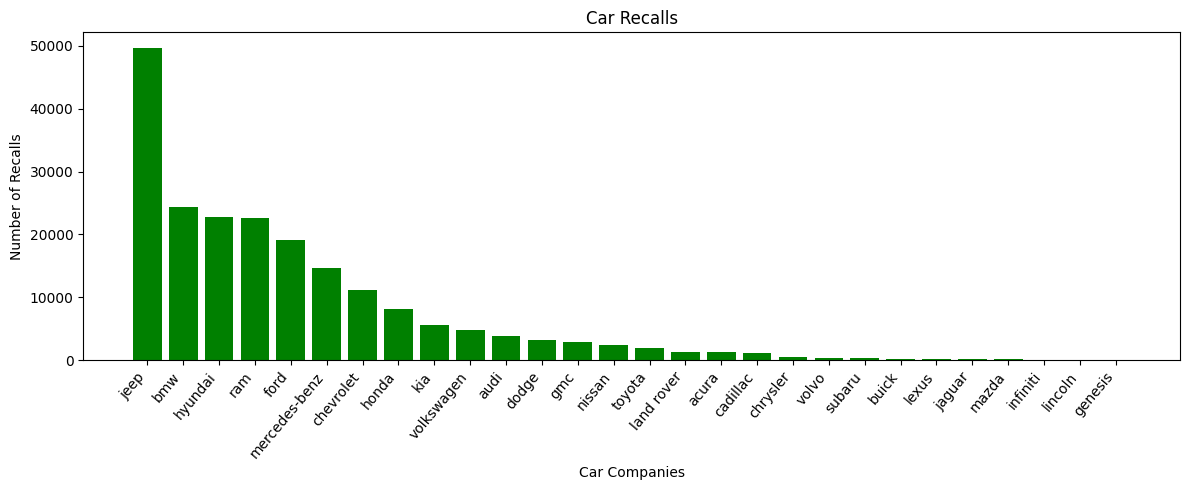

In [768]:

# Group by 'make' and count recalls (assuming one row = one recall)
countRecalls = joined_df.groupby('make')['file'].count().sort_values(ascending=False)
print (countRecalls)

# Plot
plt.figure(figsize=(12, 5))
plt.bar(countRecalls.index, countRecalls.values, color='green')
plt.xlabel('Car Companies')
plt.ylabel('Number of Recalls')
plt.title('Car Recalls')
plt.xticks(rotation= 50, ha='right')
plt.tight_layout()
plt.show()

### Jeep vehicles returns the hightest amount of recalls amongst 2024 vehicles.


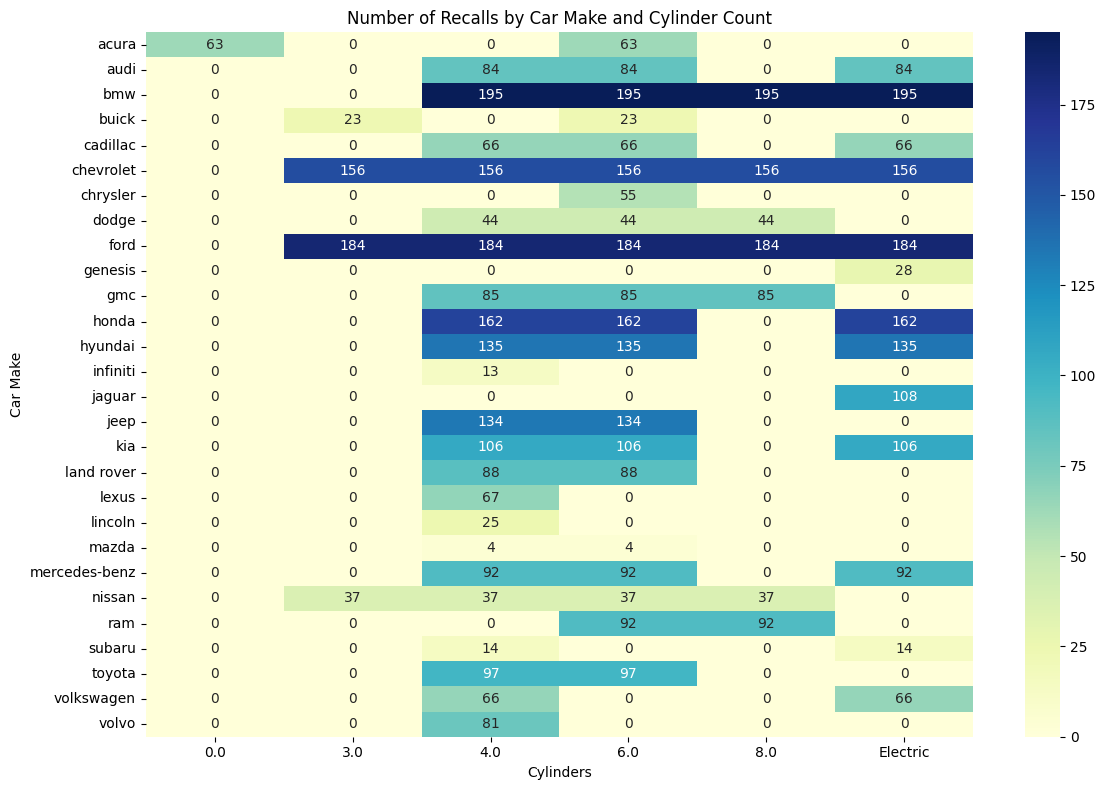

In [769]:
heat_df = joined_df.dropna(subset=['make', 'cylinders', 'file'])

# Group and pivot for heatmap
recall_counts = (
    heat_df.groupby(['make', 'cylinders'])['file']
    .nunique()
    .reset_index()
    .pivot(index='make', columns='cylinders', values='file')
    .fillna(0)
)

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(recall_counts, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title('Number of Recalls by Car Make and Cylinder Count')
plt.xlabel('Cylinders')
plt.ylabel('Car Make')
plt.tight_layout()
plt.show()

### From this chart we see that V3.0 and V8.0 cylinders has the fewest amount listed of recalls. The 4.0 cylinder Mazda and Infiniti has the lowest reported recalls.


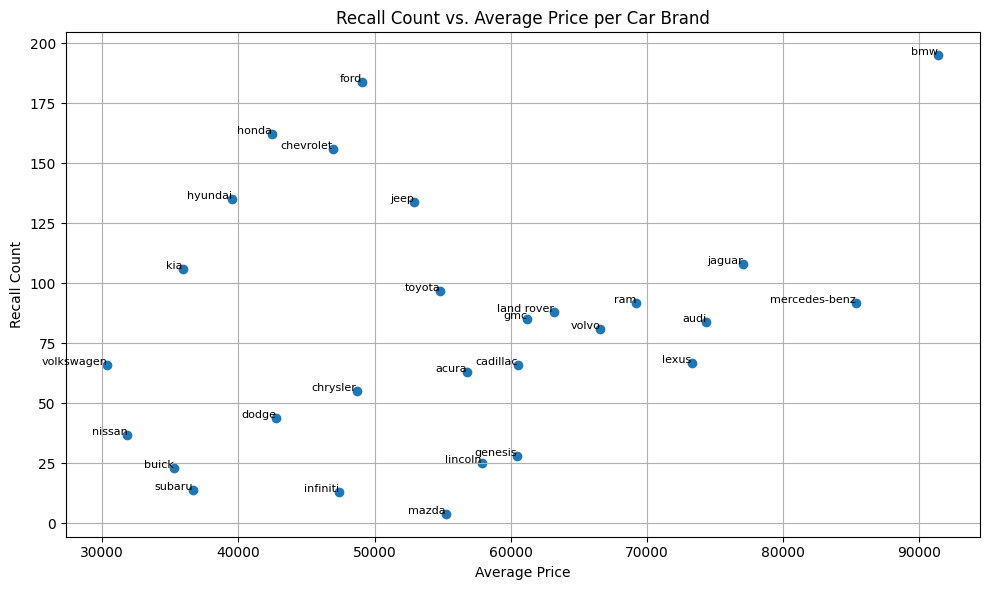

In [770]:
# Step 1: Group data to get recall count and average price per make
recall_price_df = joined_df.groupby('make').agg({
    'file': 'nunique',      # unique recall files per brand
    'price': 'mean'         # average price per brand
}).rename(columns={'file': 'recall_count', 'price': 'avg_price'})

# Step 2: Remove missing values if any
recall_price_df.dropna(subset=['avg_price'], inplace=True)

# Step 3: Plot scatter chart
plt.figure(figsize=(10, 6))
plt.scatter(recall_price_df['avg_price'], recall_price_df['recall_count'])

# Annotate some points for clarity
for make, row in recall_price_df.iterrows():
    plt.text(row['avg_price'], row['recall_count'], make, fontsize=8, ha='right')

plt.xlabel('Average Price')
plt.ylabel('Recall Count')
plt.title('Recall Count vs. Average Price per Car Brand')
plt.grid(True)
plt.tight_layout()
plt.show()


In [771]:
def check_vehicle_recalls(joined_df):
    # Prompt user for input
    year = input("Enter vehicle year (e.g., 2024): ").strip()
    make = input("Enter car make (e.g., Toyota): ").strip().title()
    model = input("Enter car model (e.g., Camry): ").strip().title()

    # Filter dataset for the user’s input
    match = joined_df[
        (joined_df['year'].astype(str) == year) &
        (joined_df['make'].str.title() == make) &
        (joined_df['model'].str.title() == model)
    ]

    # Output result
    if not match.empty:
        print("Huge RED FLAGS. Your selection has recalls.")
    else:
        print("Good choice. No recalls detected.")

check_vehicle_recalls(joined_df)


Good choice. No recalls detected.
